# 阶段三：探索性数据分析 / Stage 3: Exploratory Data Analysis

本 Notebook 调用 `src/credit_risk/analysis.py` 中经过测试的逻辑，生成双语 EDA 报告和决策相关图表。相关性仅表示关联，不表示因果关系。

This notebook calls the tested logic in `src/credit_risk/analysis.py` to generate the bilingual EDA report and decision-relevant figures. Correlation indicates association, not causation.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from credit_risk.analysis import (
    compare_split_distributions,
    format_eda_report,
    generate_eda_figures,
    summarize_categorical_features,
    summarize_numeric_features,
    summarize_repayment_status,
)
from credit_risk.data import RAW_XLS_NAME, load_dataset
from credit_risk.modeling import split_dataset

In [2]:
data_path = PROJECT_ROOT / 'data' / 'raw' / RAW_XLS_NAME
frame = load_dataset(data_path)
splits = split_dataset(frame)
numeric_summary = summarize_numeric_features(frame)
categorical_summary = summarize_categorical_features(frame)
repayment_summary = summarize_repayment_status(frame)
split_comparison = compare_split_distributions(splits)

report_path = PROJECT_ROOT / 'reports' / 'eda_report.md'
figure_directory = PROJECT_ROOT / 'reports' / 'figures'
figure_paths = generate_eda_figures(frame, splits, figure_directory)
report_path.write_text(format_eda_report(frame, splits), encoding='utf-8')

print(f'Data shape / 数据规模: {frame.shape}')
print(f'Default rate / 违约率: {frame.default_next_month.mean():.2%}')
print(f'Report / 报告: {report_path.relative_to(PROJECT_ROOT)}')
numeric_summary

Data shape / 数据规模: (30000, 25)
Default rate / 违约率: 22.12%
Report / 报告: reports\eda_report.md


,minimum,p01,median,p99,maximum,zero_share,negative_share,skewness
credit_limit,10000,10000.00,140000.0,500000.00,1000000,0.000000,0.000000,0.992867
age,21,22.00,34.0,60.00,79,0.000000,0.000000,0.732246
bill_amount_sep,-165580,-81.00,22381.5,350110.68,964511,0.066933,0.019667,2.663861
bill_amount_aug,-69777,-200.00,21200.0,337495.28,983931,0.083533,0.022300,2.705221
bill_amount_jul,-157264,-200.00,20088.5,325030.39,1664089,0.095667,0.021833,3.087830
bill_amount_jun,-170000,-212.02,19052.0,304997.27,891586,0.106500,0.022500,2.821965
bill_amount_may,-81334,-232.01,18104.5,285868.33,927171,0.116867,0.021833,2.876380
bill_amount_apr,-339603,-331.03,17071.0,279505.06,961664,0.134000,0.022933,2.846645
payment_amount_sep,0,0.00,2100.0,66522.18,873552,0.174967,0.000000,14.668364
payment_amount_aug,0,0.00,2009.0,76651.02,1684259,0.179867,0.000000,30.453817


In [3]:
print('Category summary / 类别汇总')
display(categorical_summary.head(30))
print('Six-month repayment summary / 六个月还款状态汇总')
repayment_summary

Category summary / 类别汇总


,feature,value,count,share,default_rate
0,sex,1,11888,0.396267,0.241672
1,sex,2,18112,0.603733,0.207763
2,education,0,14,0.000467,0.000000
3,education,1,10585,0.352833,0.192348
4,education,2,14030,0.467667,0.237349
5,education,3,4917,0.163900,0.251576
6,education,4,123,0.004100,0.056911
7,education,5,280,0.009333,0.064286
8,education,6,51,0.001700,0.156863
9,marital_status,0,54,0.001800,0.092593


Six-month repayment summary / 六个月还款状态汇总


,month,status,count,share,default_rate
0,repayment_status_apr,-2,4895,0.163167,0.200409
1,repayment_status_apr,-1,5740,0.191333,0.169861
2,repayment_status_apr,0,16286,0.542867,0.188444
3,repayment_status_apr,2,2766,0.092200,0.506508
4,repayment_status_apr,3,184,0.006133,0.641304
...,...,...,...,...,...
59,repayment_status_sep,4,76,0.002533,0.684211
60,repayment_status_sep,5,26,0.000867,0.500000
61,repayment_status_sep,6,11,0.000367,0.545455
62,repayment_status_sep,7,9,0.000300,0.777778


In [4]:
split_comparison['target_rates'], split_comparison['numeric'], split_comparison['categorical']

({'train': 0.2212222222222222,
  'validation': 0.22116666666666668,
  'test': 0.22116666666666668},
                     validation_standardized_mean_difference  \
 feature                                                       
 credit_limit                                      -0.000261   
 age                                                0.017792   
 bill_amount_sep                                    0.025795   
 bill_amount_aug                                    0.024443   
 bill_amount_jul                                    0.017279   
 bill_amount_jun                                    0.012440   
 bill_amount_may                                    0.012578   
 bill_amount_apr                                    0.019281   
 payment_amount_sep                                -0.005764   
 payment_amount_aug                                 0.002500   
 payment_amount_jul                                -0.009158   
 payment_amount_jun                                -0.001659   
 pay

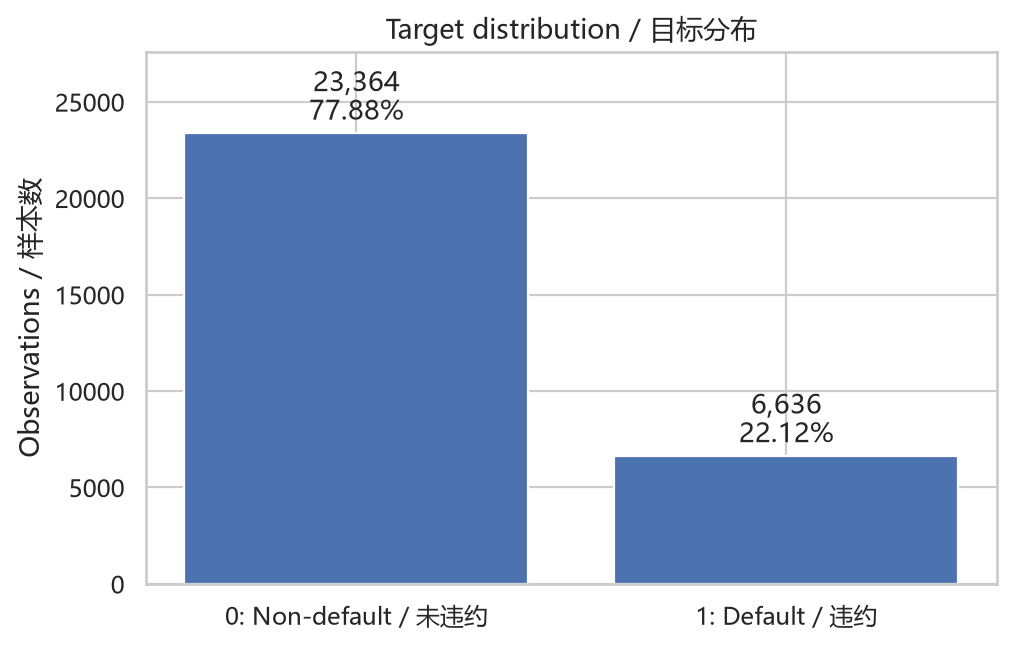

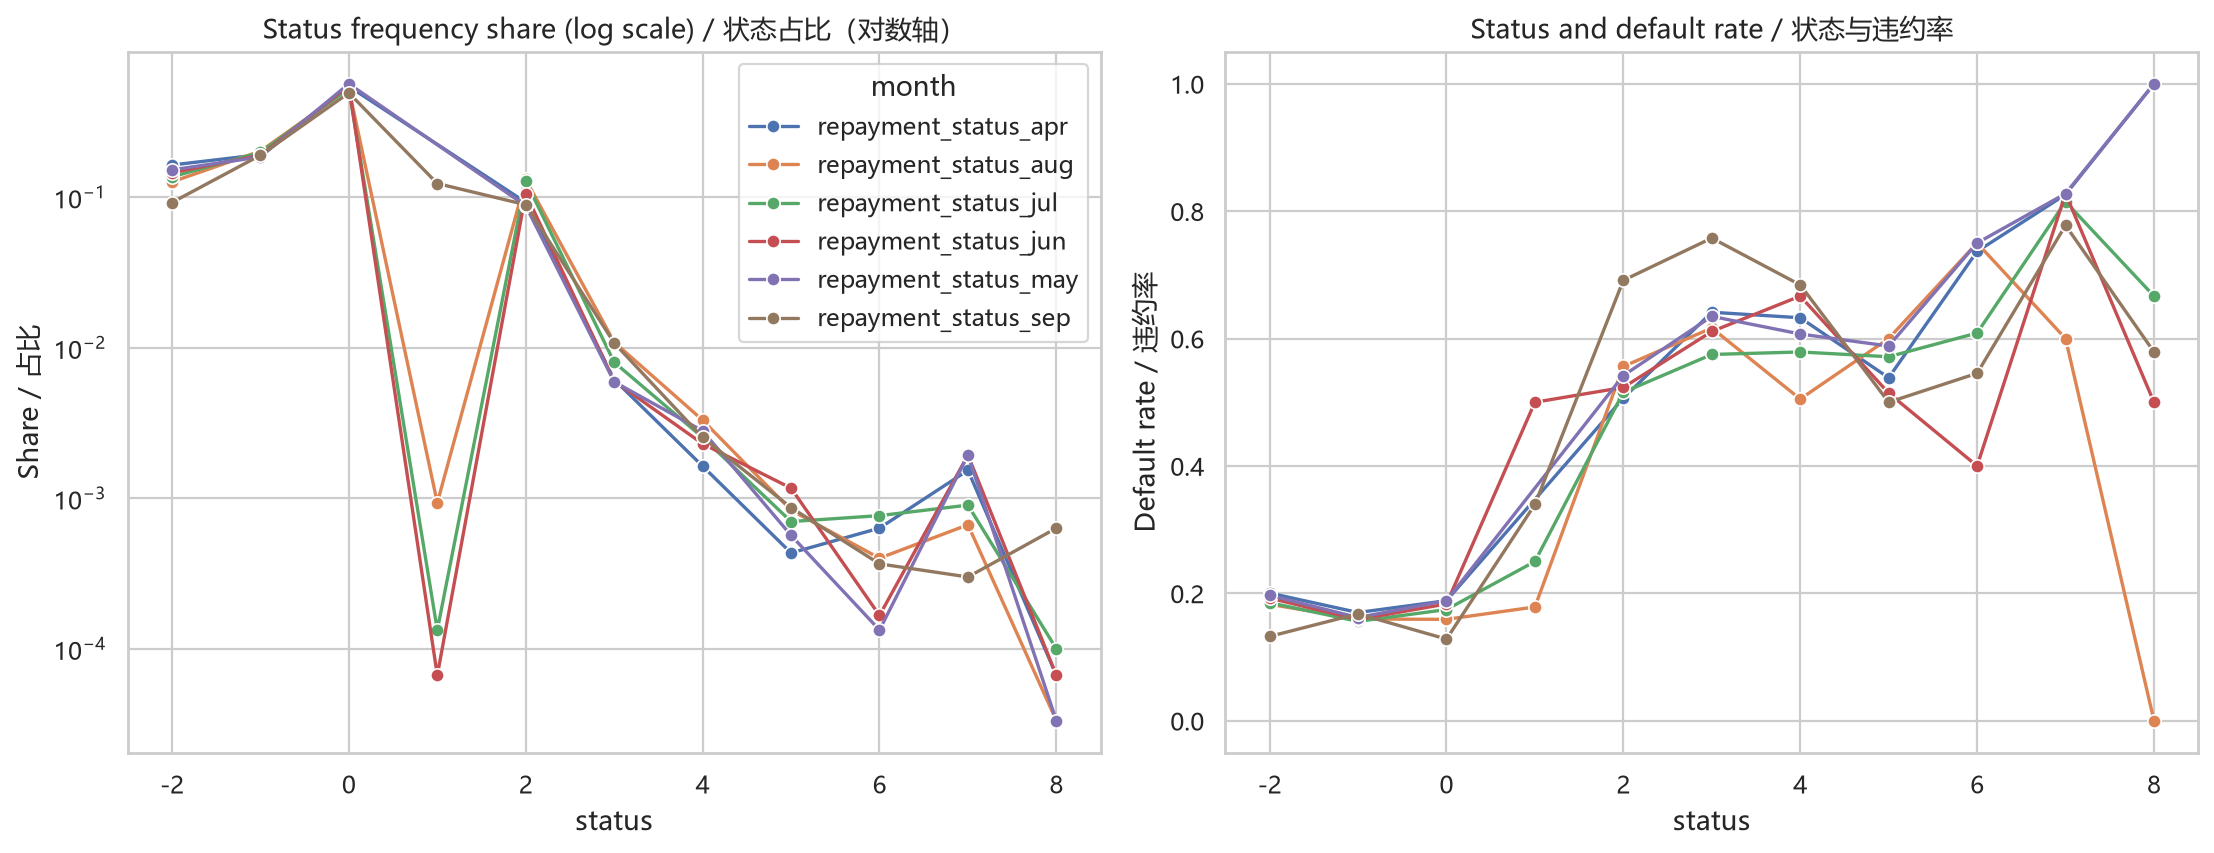

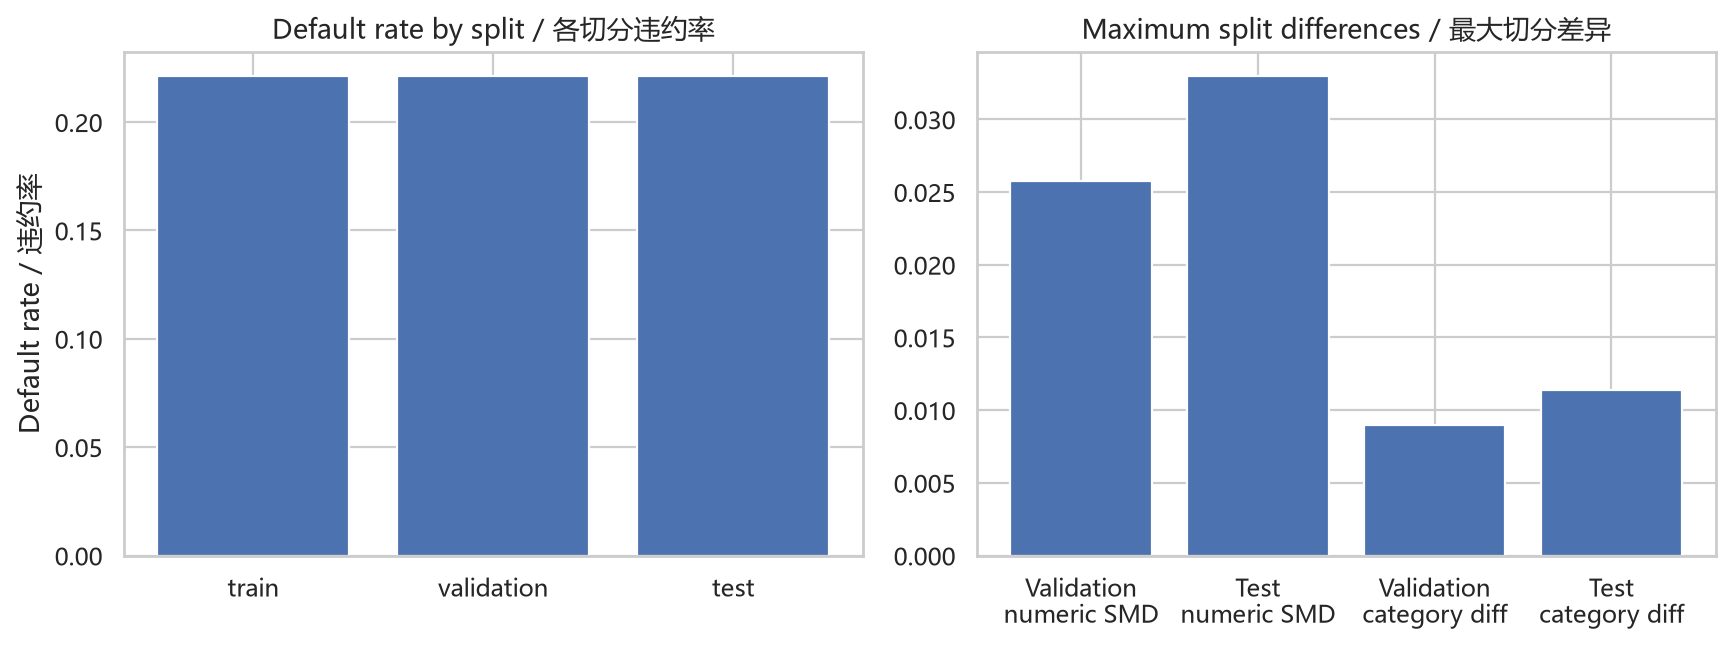

In [5]:
display(Image(filename=str(figure_directory / 'eda_target_distribution.png')))
display(Image(filename=str(figure_directory / 'eda_repayment_status.png')))
display(Image(filename=str(figure_directory / 'eda_split_comparison.png')))